# Import packages

In [1]:
# Load packages

!pip -q install chess
!pip -q install chess pyarrow tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json, time
import kagglehub
import chess.pgn
import random
import pyarrow as pa
import pyarrow.parquet as pq

from pathlib import Path
from tqdm import tqdm
from ast import literal_eval
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict, Counter


#mount drive
from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 42.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Mounted at /content/drive


# Unzip the data (only needed 1x)

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

#unzip file in drive folder Howest_project/Lichess Elite Database.7z
!apt-get -qq install -y p7zip-full

!7z x \
"/content/drive/MyDrive/Howest_project/LichessEliteDatabase.7z" \
-o"/content/drive/MyDrive/Howest_project/LichessEliteDatabase_extracted"


print('Data source unzipped.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/Howest_project/                                                1 file, 610138124 bytes (582 MiB)

Extracting archive: /content/drive/MyDrive/Howest_project/LichessEliteDatabase.7z
--
Path = /content/drive/MyDrive/Howest_project/LichessEliteDatabase.7z
Type = 7z
Physical Size = 610138124
Headers Size = 1410
Method = LZMA2:24
Solid = +
Blocks = 2

  0%      0% 11 - Lichess Elite Database/lichess_elite_2014-08.pgn                               

# Define paths

In [2]:
PGN_ROOT = Path("/content/drive/MyDrive/Howest_project/LichessEliteDatabase_extracted/LichessEliteDatabase")
PGN_FILES = sorted(PGN_ROOT.glob("*.pgn"))

OUT_DIR = Path("/content/drive/MyDrive/Howest_project/derived_data")
DATASET_DIR = OUT_DIR / "chess_v1_dataset"      # folder met part-files
DATASET_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = DATASET_DIR / "_manifest.json"

A_PARTIAL_DIR = OUT_DIR / "agg_position_move_partials"   # partials (one per event-part)
A_FINAL_DIR   = OUT_DIR / "agg_position_move"            # Table A (final dataset folder)
B_FINAL_DIR   = OUT_DIR / "agg_position_stats"           # Table B (final dataset folder)


print("PGN files:", len(PGN_FILES))
print("Dataset dir:", DATASET_DIR)
print("Manifest:", MANIFEST_PATH)

PGN files: 79
Dataset dir: /content/drive/MyDrive/Howest_project/derived_data/chess_v1_dataset
Manifest: /content/drive/MyDrive/Howest_project/derived_data/chess_v1_dataset/_manifest.json


# Analyse data set (only needed 1x)

“Normalized FEN” functie (belangrijk voor matching)

Veel PGN-posities verschillen enkel in halfmove/fullmove counters (en soms en-passant).
Voor “similar games” wil je die meestal negeren.

In [ ]:
def normalized_fen(board: chess.Board, ignore_ep: bool = True) -> str:
    # FEN velden: piece placement / side to move / castling / en-passant / halfmove / fullmove
    parts = board.fen().split(" ")
    # drop halfmove & fullmove
    parts = parts[:4]
    if ignore_ep:
        parts[3] = "-"  # en-passant vaak ruis
    return " ".join(parts)


Streaming audit script

In [ ]:
def analyze_position_counts(pos_counts):
    total_positions = len(pos_counts)
    ge_5 = sum(1 for c in pos_counts.values() if c >= 5)
    ge_10 = sum(1 for c in pos_counts.values() if c >= 10)

    print(f"% posities met >= 5 voorbeelden:  {100*ge_5/total_positions:.2f}%")
    print(f"% posities met >= 10 voorbeelden: {100*ge_10/total_positions:.2f}%")

#analyze_position_counts(pos_counts)

In [ ]:
MAX_GAMES = 500_000        # pas aan (bv. 50_000 of 300_000)
PLIES_PER_GAME = 20        # hoeveel plies (half-moves) per game posities tellen
IGNORE_EP = True

pos_counts = Counter()                 # hoe vaak komt een positie voor
pos_nextmove_counts = defaultdict(Counter)  # per positie: welke next moves (UCI) komen voor
games_seen = 0

# optioneel: shuffle files om sneller een representatieve sample te krijgen
files = PGN_FILES.copy()
random.shuffle(files)

for pgn_path in files:
    with open(pgn_path, "r", encoding="utf-8", errors="ignore") as f:
        while games_seen < MAX_GAMES:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            board = game.board()
            ply = 0
            for move in game.mainline_moves():
                fen_key = normalized_fen(board, ignore_ep=IGNORE_EP)
                pos_counts[fen_key] += 1

                # next move label (wat gaan we aanbevelen)
                pos_nextmove_counts[fen_key][move.uci()] += 1

                board.push(move)
                ply += 1
                if ply >= PLIES_PER_GAME:
                    break

            games_seen += 1
            #print teller
            if games_seen % 5000 == 0 :
                print(f"Games processed: {games_seen}")
                analyze_position_counts(pos_counts)

    if games_seen >= MAX_GAMES:
        break

print("Games verwerkt:", games_seen)
print("Unieke posities:", len(pos_counts))


Games processed: 5000
% posities met >= 5 voorbeelden:  3.84%
% posities met >= 10 voorbeelden: 1.64%
Games processed: 10000
% posities met >= 5 voorbeelden:  4.15%
% posities met >= 10 voorbeelden: 1.79%
Games processed: 15000
% posities met >= 5 voorbeelden:  4.42%
% posities met >= 10 voorbeelden: 1.90%
Games processed: 20000
% posities met >= 5 voorbeelden:  4.59%
% posities met >= 10 voorbeelden: 1.97%
Games processed: 25000
% posities met >= 5 voorbeelden:  4.67%
% posities met >= 10 voorbeelden: 2.03%
Games processed: 30000
% posities met >= 5 voorbeelden:  4.81%
% posities met >= 10 voorbeelden: 2.10%
Games processed: 35000
% posities met >= 5 voorbeelden:  4.90%
% posities met >= 10 voorbeelden: 2.14%
Games processed: 40000
% posities met >= 5 voorbeelden:  4.96%
% posities met >= 10 voorbeelden: 2.20%
Games processed: 45000
% posities met >= 5 voorbeelden:  5.04%
% posities met >= 10 voorbeelden: 2.24%
Games processed: 50000
% posities met >= 5 voorbeelden:  5.12%
% posities 

Hoe vaak kunnen we een top 3 geven?

In [ ]:
has_top3 = sum(1 for fen, mv in pos_nextmove_counts.items() if len(mv) >= 3)
print(f"% posities met >= 3 verschillende next moves: {100*has_top3/total_positions:.2f}%")

% posities met >= 3 verschillende next moves: 18.37%


# Prepare data (only needed 1x)

V1 Schema + helpers

In [ ]:
schema = pa.schema([
    ("game_id", pa.string()),
    ("ply", pa.int32()),
    ("fen_norm", pa.string()),
    ("side_to_move", pa.string()),
    ("castling_mask", pa.string()),
    ("history_last6_uci", pa.string()),
    ("next_move_uci", pa.string()),
    ("white_elo", pa.int16()),
    ("black_elo", pa.int16()),
    ("time_control", pa.string()),
    ("result", pa.string()),
])

def safe_int16(x):
    try:
        v = int(x)
        if -32768 <= v <= 32767:
            return v
    except:
        pass
    return None

def normalized_fen(board):
    parts = board.fen().split(" ")
    parts = parts[:4]       # piece, side, castling, ep
    parts[3] = "-"          # ignore en-passant for stability
    return " ".join(parts)

def encode_history_last6(history_uci):
    last6 = history_uci[-6:]
    pad = ["START"] * (6 - len(last6))
    return "|".join(pad + last6)


Adaptive cutoff logic:

We bewaren altijd minstens BASE_PLIES (bv. 80).

Daarna stoppen we alleen als de positie “endgame-achtig en sparse” is.

In [ ]:
# --- Adaptive cutoff parameters ---
BASE_PLIES = 80               # altijd minstens dit aantal plies bewaren
MAX_PLIES_HARD = 240          # harde veiligheidslimiet (optioneel)
ENDGAME_MATERIAL_MAX = 14     # totale niet-koning materiaalwaarde (beide spelers samen)
STOP_IF_NO_QUEENS = True      # extra filter: pas afkappen als er geen dames meer zijn

PIECE_VALUES = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9
}

def material_total_excl_kings(board: chess.Board) -> int:
    total = 0
    for piece_type, val in PIECE_VALUES.items():
        total += len(board.pieces(piece_type, chess.WHITE)) * val
        total += len(board.pieces(piece_type, chess.BLACK)) * val
    return total

def has_any_queen(board: chess.Board) -> bool:
    return (len(board.pieces(chess.QUEEN, chess.WHITE)) + len(board.pieces(chess.QUEEN, chess.BLACK))) > 0

def should_stop_adaptive(ply: int, board: chess.Board) -> bool:
    # 1) we stoppen nooit vóór BASE_PLIES
    if ply < BASE_PLIES:
        return False

    # 2) harde limiet (veiligheid)
    if MAX_PLIES_HARD is not None and ply >= MAX_PLIES_HARD:
        return True

    # 3) endgame-heuristiek
    mat = material_total_excl_kings(board)
    if mat <= ENDGAME_MATERIAL_MAX:
        if STOP_IF_NO_QUEENS and has_any_queen(board):
            return False
        return True

    return False


Manifest helpers + output pad

In [ ]:
def load_manifest(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {"processed": {}, "created_at": time.time()}

def save_manifest(path: Path, manifest: dict):
    tmp = path.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2, sort_keys=True)
    os.replace(tmp, path)

def output_part_path(pgn_path: Path) -> Path:
    safe_name = pgn_path.stem.replace(" ", "_")
    return DATASET_DIR / f"{safe_name}.parquet"


Verwerking per pgn-file (crash safe + adaptive)

In [ ]:
def process_single_pgn_to_parquet_adaptive(
    pgn_path: Path,
    out_path: Path,
    chunk_rows=250_000
):
    tmp_out = out_path.with_suffix(".parquet.tmp")
    writer = pq.ParquetWriter(tmp_out.as_posix(), schema=schema, compression="snappy")

    buffer = {name: [] for name in schema.names}
    rows_written = 0
    games_seen = 0

    try:
        with open(pgn_path, "r", encoding="utf-8", errors="ignore") as f:
            while True:
                game = chess.pgn.read_game(f)
                if game is None:
                    break

                headers = game.headers
                white_elo = safe_int16(headers.get("WhiteElo"))
                black_elo = safe_int16(headers.get("BlackElo"))
                time_control = headers.get("TimeControl")
                result = headers.get("Result")

                game_id = (
                    f"{pgn_path.name}:"
                    f"{headers.get('Site','')}:"
                    f"{headers.get('UTCDate','')}:"
                    f"{headers.get('UTCTime','')}:"
                    f"{headers.get('White','')}:"
                    f"{headers.get('Black','')}"
                )

                board = game.board()
                history_uci = []
                ply = 0

                for move in game.mainline_moves():
                    # check adaptive stop BEFORE recording current state?
                    # We want to record the current state and its next_move label,
                    # so stop check is at the start of loop.
                    if should_stop_adaptive(ply, board):
                        break

                    fen = normalized_fen(board)
                    side = "w" if board.turn else "b"
                    castling = board.castling_xfen()
                    hist = encode_history_last6(history_uci)
                    nxt = move.uci()

                    buffer["game_id"].append(game_id)
                    buffer["ply"].append(ply)
                    buffer["fen_norm"].append(fen)
                    buffer["side_to_move"].append(side)
                    buffer["castling_mask"].append(castling)
                    buffer["history_last6_uci"].append(hist)
                    buffer["next_move_uci"].append(nxt)
                    buffer["white_elo"].append(white_elo)
                    buffer["black_elo"].append(black_elo)
                    buffer["time_control"].append(time_control)
                    buffer["result"].append(result)

                    rows_written += 1

                    # advance
                    board.push(move)
                    history_uci.append(nxt)
                    ply += 1

                    if rows_written % chunk_rows == 0:
                        table = pa.Table.from_pydict(buffer, schema=schema)
                        writer.write_table(table)
                        buffer = {name: [] for name in schema.names}

                games_seen += 1
                # print progress every 10,000 games
                if games_seen % 10000 == 0:
                    print(f"  Processed {games_seen} games, {rows_written} rows from {pgn_path.name}")


        if len(buffer["game_id"]) > 0:
            table = pa.Table.from_pydict(buffer, schema=schema)
            writer.write_table(table)

    finally:
        writer.close()

    os.replace(tmp_out, out_path)
    return games_seen, rows_written

Runner: hervatbaar, verwerkt enkel ontbrekende pgn's

In [ ]:
# --- ADD/REPLACE: integrity check + report utilities, and update runner ---

import pyarrow.parquet as pq
import pyarrow.dataset as ds
from collections import defaultdict
from tqdm import tqdm
import time

def part_is_valid(out_path: Path, min_rows: int = 1) -> bool:
    """
    Integrity check:
    - file exists
    - can be opened as parquet
    - has at least `min_rows` rows
    """
    if not out_path.exists():
        return False
    try:
        pf = pq.ParquetFile(out_path.as_posix())
        return pf.metadata.num_rows >= min_rows
    except Exception:
        return False

def report_avg_plies_per_game(dataset_dir: Path, sample_games: int | None = 200_000) -> dict:
    """
    Report (approx):
    - average retained plies per game_id
    - median / p90
    Uses a streaming scan over parquet dataset. Optionally limit number of distinct games scanned.
    """
    dataset = ds.dataset(dataset_dir, format="parquet")
    scanner = dataset.scanner(columns=["game_id", "ply"])

    plies_per_game = defaultdict(int)
    games_seen = 0

    for batch in scanner.to_batches():
        g = batch.column("game_id").to_pylist()
        p = batch.column("ply").to_pylist()

        for gid, ply in zip(g, p):
            # retained plies per game_id ≈ max ply + 1
            if ply + 1 > plies_per_game[gid]:
                plies_per_game[gid] = ply + 1

        if sample_games is not None and len(plies_per_game) >= sample_games:
            break

    vals = list(plies_per_game.values())
    if not vals:
        return {"games": 0}

    vals_sorted = sorted(vals)
    n = len(vals_sorted)
    avg = sum(vals_sorted) / n
    median = vals_sorted[n // 2]
    p90 = vals_sorted[int(0.9 * (n - 1))]

    return {
        "games": n,
        "avg_plies": round(avg, 2),
        "median_plies": median,
        "p90_plies": p90,
        "note": "Computed on distinct game_id max(ply)+1; may be sampled if sample_games set."
    }

def build_v1_dataset_resumable_adaptive(
    pgn_files,
    chunk_rows=250_000,
    integrity_min_rows=1,
    rebuild_corrupt=True
):
    """
    Resume-safe runner with integrity checks:
    - If part-file exists and is valid -> skip
    - If exists but invalid (0 rows / unreadable) -> rebuild (optional)
    - If missing -> process
    Always updates manifest.
    """
    manifest = load_manifest(MANIFEST_PATH)

    for pgn_path in tqdm(pgn_files, desc="PGN → Parquet dataset (adaptive + integrity)"):
        out_path = output_part_path(pgn_path)

        # If part exists, validate it
        if out_path.exists():
            ok = part_is_valid(out_path, min_rows=integrity_min_rows)
            if ok:
                if pgn_path.name not in manifest["processed"]:
                    manifest["processed"][pgn_path.name] = {
                        "status": "done",
                        "output": out_path.name,
                        "note": "file existed and passed integrity check"
                    }
                    save_manifest(MANIFEST_PATH, manifest)
                continue

            # Corrupt/empty file: rebuild if allowed
            if rebuild_corrupt:
                # remove bad file and any leftover tmp
                try:
                    out_path.unlink(missing_ok=True)
                except TypeError:
                    if out_path.exists():
                        out_path.unlink()
                tmp_bad = out_path.with_suffix(".parquet.tmp")
                if tmp_bad.exists():
                    tmp_bad.unlink()

                manifest["processed"][pgn_path.name] = {
                    "status": "rebuilding",
                    "output": out_path.name,
                    "note": "failed integrity check; rebuilding"
                }
                save_manifest(MANIFEST_PATH, manifest)
            else:
                manifest["processed"][pgn_path.name] = {
                    "status": "invalid",
                    "output": out_path.name,
                    "note": "failed integrity check; not rebuilt"
                }
                save_manifest(MANIFEST_PATH, manifest)
                continue

        # Process (missing or rebuild)
        start = time.time()
        games, rows = process_single_pgn_to_parquet_adaptive(
            pgn_path, out_path, chunk_rows=chunk_rows
        )

        manifest["processed"][pgn_path.name] = {
            "status": "done",
            "output": out_path.name,
            "games": games,
            "rows": rows,
            "seconds": round(time.time() - start, 2),
            "processed_at": time.time(),
            "adaptive_params": {
                "BASE_PLIES": BASE_PLIES,
                "MAX_PLIES_HARD": MAX_PLIES_HARD,
                "ENDGAME_MATERIAL_MAX": ENDGAME_MATERIAL_MAX,
                "STOP_IF_NO_QUEENS": STOP_IF_NO_QUEENS
            }
        }
        save_manifest(MANIFEST_PATH, manifest)

    print("✅ Klaar. Dataset parts:", len(list(DATASET_DIR.glob("*.parquet"))))
    print("📌 Manifest:", MANIFEST_PATH)

    # Built-in quick report
    rep = report_avg_plies_per_game(DATASET_DIR, sample_games=200_000)
    print("📊 Adaptive cutoff report:", rep)


# --- RUN (same call signature as before, now with integrity + report) ---
build_v1_dataset_resumable_adaptive(
    PGN_FILES,
    chunk_rows=250_000,
    integrity_min_rows=1,
    rebuild_corrupt=True
)


PGN → Parquet dataset (adaptive + integrity): 100%|██████████| 79/79 [6:30:02<00:00, 296.24s/it] 


✅ Klaar. Dataset parts: 79
📌 Manifest: /content/drive/MyDrive/Howest_project/derived_data/chess_v1_dataset/_manifest.json
📊 Adaptive cutoff report: {'games': 200731, 'avg_plies': 74.14, 'median_plies': 76, 'p90_plies': 107, 'note': 'Computed on distinct game_id max(ply)+1; may be sampled if sample_games set.'}


# Import data (parquet files)

Print eerste 10 rijen uit parquet files  


In [ ]:
# Lezen als 1 dataset
# df_chess_moves = pd.read_parquet(DATASET_DIR)
# df_chess_moves.head(5)
all_parquet_files = list(DATASET_DIR.glob('*.parquet'))
sample_file = random.choice(all_parquet_files)
print(f"Geselecteerde file: {sample_file.name}")

pf = pq.ParquetFile(sample_file)
table = pf.read_row_group(0)
display(table.to_pandas().head(10))


Geselecteerde file: lichess_elite_2018-06.parquet


,game_id,ply,fen_norm,side_to_move,castling_mask,history_last6_uci,next_move_uci,white_elo,black_elo,time_control,result
0,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,0,rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w ...,w,KQkq,START|START|START|START|START|START,d2d4,2372,2521,180+0,0-1
1,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,1,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,b,KQkq,START|START|START|START|START|d2d4,d7d5,2372,2521,180+0,0-1
2,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,2,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,w,KQkq,START|START|START|START|d2d4|d7d5,c2c3,2372,2521,180+0,0-1
3,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,3,rnbqkbnr/ppp1pppp/8/3p4/3P4/2P5/PP2PPPP/RNBQKB...,b,KQkq,START|START|START|d2d4|d7d5|c2c3,g8f6,2372,2521,180+0,0-1
4,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,4,rnbqkb1r/ppp1pppp/5n2/3p4/3P4/2P5/PP2PPPP/RNBQ...,w,KQkq,START|START|d2d4|d7d5|c2c3|g8f6,g1f3,2372,2521,180+0,0-1
5,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,5,rnbqkb1r/ppp1pppp/5n2/3p4/3P4/2P2N2/PP2PPPP/RN...,b,KQkq,START|d2d4|d7d5|c2c3|g8f6|g1f3,b7b6,2372,2521,180+0,0-1
6,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,6,rnbqkb1r/p1p1pppp/1p3n2/3p4/3P4/2P2N2/PP2PPPP/...,w,KQkq,d2d4|d7d5|c2c3|g8f6|g1f3|b7b6,c1f4,2372,2521,180+0,0-1
7,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,7,rnbqkb1r/p1p1pppp/1p3n2/3p4/3P1B2/2P2N2/PP2PPP...,b,KQkq,d7d5|c2c3|g8f6|g1f3|b7b6|c1f4,c8b7,2372,2521,180+0,0-1
8,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,8,rn1qkb1r/pbp1pppp/1p3n2/3p4/3P1B2/2P2N2/PP2PPP...,w,KQkq,c2c3|g8f6|g1f3|b7b6|c1f4|c8b7,b1d2,2372,2521,180+0,0-1
9,lichess_elite_2018-06.pgn:?:2018.05.31:22:01:4...,9,rn1qkb1r/pbp1pppp/1p3n2/3p4/3P1B2/2P2N2/PP1NPP...,b,KQkq,g8f6|g1f3|b7b6|c1f4|c8b7|b1d2,e7e6,2372,2521,180+0,0-1


In [ ]:
#print het totaal aantal rijen uit alle parquet files
total_rows = 0
for file in all_parquet_files:
    pf = pq.ParquetFile(file)
    total_rows += pf.metadata.num_rows
print(f"Totaal aantal rijen: {total_rows}")

Totaal aantal rijen: 288973357


# Build score tables (only needed 1x)

In [ ]:
# =========================
# BUILD TABLE A + TABLE B
# (Option B: batch/partials + reduce)
# Uses DuckDB for out-of-core groupby (fast, low RAM).
# =========================

!pip -q install duckdb pyarrow

from pathlib import Path
import duckdb
import json, os, time

# -------- PATHS (adjust if needed) --------

A_PARTIAL_DIR = OUT_DIR / "agg_position_move_partials"   # partials (one per event-part)
A_FINAL_DIR   = OUT_DIR / "agg_position_move"            # Table A (final dataset folder)
B_FINAL_DIR   = OUT_DIR / "agg_position_stats"           # Table B (final dataset folder)

A_PARTIAL_DIR.mkdir(parents=True, exist_ok=True)
A_FINAL_DIR.mkdir(parents=True, exist_ok=True)
B_FINAL_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = A_PARTIAL_DIR / "_manifest.json"

# -------- SETTINGS --------
ELO_REF = 2000.0
ELO_FALLBACK = 2000.0
ELO_WEIGHT_MIN = 0.5
ELO_WEIGHT_MAX = 2.0

# -------- MANIFEST helpers --------
def load_manifest(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {"processed": {}, "created_at": time.time()}

def save_manifest(path: Path, manifest: dict):
    tmp = path.with_suffix(".tmp")
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2, sort_keys=True)
    os.replace(tmp, path)

def partial_out_path(event_part: Path) -> Path:
    # keep same stem; store partial aggregation parquet
    return A_PARTIAL_DIR / f"{event_part.stem}__A_partial.parquet"

# -------- SQL snippets --------
# pos_key = "piecePlacement sideToMove" ONLY (no castling, no ep, no counters)
# derived from fen_norm: "pieces side castling -"
POS_KEY_EXPR = "split_part(fen_norm, ' ', 1) || ' ' || split_part(fen_norm, ' ', 2)"

# outcome from perspective of side_to_move:
# win=1.0 draw=0.5 loss=0.0
OUTCOME_EXPR = """
CASE
  WHEN result = '1/2-1/2' THEN 0.5
  WHEN result = '1-0' THEN CASE WHEN side_to_move = 'w' THEN 1.0 ELSE 0.0 END
  WHEN result = '0-1' THEN CASE WHEN side_to_move = 'b' THEN 1.0 ELSE 0.0 END
  ELSE 0.5
END
"""

# avg elo per row (fallback if null)
AVG_ELO_EXPR = f"""
( COALESCE(CAST(white_elo AS DOUBLE), {ELO_FALLBACK})
+ COALESCE(CAST(black_elo AS DOUBLE), {ELO_FALLBACK}) ) / 2.0
"""

# capped elo weight
ELO_WEIGHT_EXPR = f"""
LEAST({ELO_WEIGHT_MAX},
  GREATEST({ELO_WEIGHT_MIN},
    ({AVG_ELO_EXPR}) / {ELO_REF}
  )
)
"""

# -------- 1) BUILD TABLE A PARTIALS (batch per event part-file) --------
con = duckdb.connect(database=":memory:")
con.execute("PRAGMA threads=4;")  # adjust as you like

event_parts = sorted(DATASET_DIR.glob("*.parquet"))
print(f"Event part-files found: {len(event_parts)}")

# manifest = load_manifest(MANIFEST_PATH)
# processed = manifest["processed"]

# for i, part in enumerate(event_parts, start=1):
#     outp = partial_out_path(part)

#     # skip if already processed and file exists
#     if outp.exists() and processed.get(part.name, {}).get("status") == "done":
#         continue

#     # (re)build partial safely
#     tmp_out = outp.with_suffix(".parquet.tmp")
#     if tmp_out.exists():
#         tmp_out.unlink()

#     t0 = time.time()

#     # Build partial aggregation for this part-file
#     # GROUP BY pos_key, castling_mask, next_move_uci
#     sql = f"""
#     COPY (
#       SELECT
#         {POS_KEY_EXPR} AS pos_key,
#         COALESCE(castling_mask, '-') AS castling_mask,
#         next_move_uci,
#         COUNT(*)::UBIGINT AS count,
#         SUM({AVG_ELO_EXPR}) AS elo_sum,
#         SUM({OUTCOME_EXPR}) AS outcome_sum,
#         SUM(({OUTCOME_EXPR}) * ({ELO_WEIGHT_EXPR})) AS elo_outcome_sum
#       FROM read_parquet('{part.as_posix()}')
#       GROUP BY 1, 2, 3
#     )
#     TO '{tmp_out.as_posix()}'
#     (FORMAT PARQUET, COMPRESSION 'SNAPPY');
#     """
#     con.execute(sql)

#     # atomic finalize
#     os.replace(tmp_out, outp)

#     processed[part.name] = {
#         "status": "done",
#         "partial": outp.name,
#         "seconds": round(time.time() - t0, 2),
#         "processed_at": time.time()
#     }
#     save_manifest(MANIFEST_PATH, manifest)

#     if i % 10 == 0:
#         print(f"Processed {i}/{len(event_parts)} part-files...")

# print("✅ Partials done:", len(list(A_PARTIAL_DIR.glob("*__A_partial.parquet"))))
# print("📌 Manifest:", MANIFEST_PATH)

# -------- 2) REDUCE PARTIALS -> FINAL TABLE A DATASET --------
# Final Table A: sum partials over same keys
# Writes to A_FINAL_DIR as dataset (multiple files)
# We clear previous output to avoid mixing old runs.
for old in A_FINAL_DIR.glob("*.parquet"):
    old.unlink()

partials_glob = (A_PARTIAL_DIR / "*__A_partial.parquet").as_posix()

sql_reduce_A = f"""
COPY (
  SELECT
    pos_key,
    castling_mask,
    next_move_uci,
    SUM(count)::UBIGINT AS count,
    SUM(elo_sum) AS elo_sum,
    SUM(outcome_sum) AS outcome_sum,
    SUM(elo_outcome_sum) AS elo_outcome_sum
  FROM read_parquet('{partials_glob}')
  GROUP BY 1, 2, 3
)
TO '{(A_FINAL_DIR / "tableA.parquet").as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
"""
con.execute(sql_reduce_A)

print("✅ Table A written (single parquet). If you want multiple part-files later, we can repartition it.")

# -------- 3) BUILD TABLE B FROM TABLE A --------
# Table B per pos_key:
# total_count, unique_moves, top1_move/top1_count, top1_share, top3_share
# (pos_key uses the same base FEN definition)
for old in B_FINAL_DIR.glob("*.parquet"):
    old.unlink()

tableA_path = (A_FINAL_DIR / "tableA.parquet").as_posix()

sql_build_B = f"""
COPY (
  WITH ranked AS (
    SELECT
      pos_key,
      next_move_uci,
      count,
      SUM(count) OVER (PARTITION BY pos_key) AS total_count,
      ROW_NUMBER() OVER (PARTITION BY pos_key ORDER BY count DESC) AS rn
    FROM read_parquet('{tableA_path}')
  ),
  agg AS (
    SELECT
      pos_key,
      MAX(total_count) AS total_count,
      COUNT(*)::INTEGER AS unique_moves,
      MAX(CASE WHEN rn = 1 THEN next_move_uci END) AS top1_move,
      MAX(CASE WHEN rn = 1 THEN count END) AS top1_count,
      (MAX(CASE WHEN rn = 1 THEN count END) * 1.0) / MAX(total_count) AS top1_share,
      (SUM(CASE WHEN rn <= 3 THEN count ELSE 0 END) * 1.0) / MAX(total_count) AS top3_share
    FROM ranked
    GROUP BY pos_key
  )
  SELECT * FROM agg
)
TO '{(B_FINAL_DIR / "tableB.parquet").as_posix()}'
(FORMAT PARQUET, COMPRESSION 'SNAPPY');
"""
con.execute(sql_build_B)

print("✅ Table B written.")

# -------- QUICK CHECK --------
con.close()

import pandas as pd
print("\nSample Table A:")
display(pd.read_parquet(A_FINAL_DIR / "tableA.parquet").head(10))

print("\nSample Table B:")
display(pd.read_parquet(B_FINAL_DIR / "tableB.parquet").head(10))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 135.2 MB/s eta 0:00:00
Event part-files found: 79


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Table A written (single parquet). If you want multiple part-files later, we can repartition it.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ Table B written.

Sample Table A:


In [ ]:
import pandas as pd

print("\nSample Table A:")
# display(pd.read_parquet(A_FINAL_DIR / "tableA.parquet").head(10))

pf = pq.ParquetFile(A_FINAL_DIR / "tableA.parquet")
table = pf.read_row_group(0)
display(table.to_pandas().head(10))

print("\nSample Table B:")
pf = pq.ParquetFile(B_FINAL_DIR / "tableB.parquet")
table = pf.read_row_group(0)
display(table.to_pandas().head(10))


Sample Table A:


,pos_key,castling_mask,next_move_uci,count,elo_sum,outcome_sum,elo_outcome_sum
0,7b/6kp/p7/1p3p2/6b1/1P1P1BP1/P1R2K2/1n6 b,-,g7g6,1,2308.5,1.0,1.154250
1,r1br2k1/ppp2pbp/n4np1/4N1B1/2P1P3/2N4P/PP3PP1/...,KQ,d8e8,8,19813.5,6.0,7.382250
2,r7/5kpp/3Qpn2/8/7P/2B2P2/5RPK/qq6 w,-,d6c7,1,2304.0,1.0,1.152000
3,rn1qk2r/pp3ppp/2p1pn2/2b4b/1P6/3B1P2/P1PBN1PP/...,kq,b4c5,1,2358.5,0.0,0.000000
4,r3kb1r/p4ppp/2p1pn2/2N5/8/P2B1b2/1PP2P1P/R1BnK...,Qkq,c5a6,1,2355.5,0.0,0.000000
5,1k5r/1pp5/8/1N1Pq3/1PB5/PK5p/2Q5/8 w,-,c2f2,1,2342.5,0.0,0.000000
6,rnb1kb1r/pp3ppp/2p2n2/8/3qP3/2N2N2/PPP3PP/R1B1...,KQkq,f3d4,38,92017.0,17.5,21.322125
7,rnb1k2r/pp3ppp/2p1p3/8/1bPPn3/2N2N2/PPK1BqPP/R...,kq,b4c3,1,2399.0,0.0,0.000000
8,4r1k1/r2p1p2/6pp/3R4/8/4PN2/1b3KPP/4R3 w,-,e1d1,1,2399.0,1.0,1.199500
9,r4rk1/Rp2ppbp/3p1np1/5b2/2BP4/1PP2N2/1P1N1PPP/...,K,a7a8,1,2399.0,0.0,0.000000



Sample Table B:


,pos_key,total_count,unique_moves,top1_move,top1_count,top1_share,top3_share
0,3r2k1/2R1pp1p/4q1p1/3p4/3Q4/1P2P1P1/P4PKP/8 b,1.0,1,e6d6,1,1.0,1.0
1,3r2k1/2R1pp2/5bp1/2N2b1p/4p3/4P1P1/P3BPKP/8 w,1.0,1,h2h4,1,1.0,1.0
2,3r2k1/2R1qpbp/r7/1N1pp3/4p3/1Q6/1P3PPP/4R1K1 b,1.0,1,e7g5,1,1.0,1.0
3,3r2k1/2R2N2/4pP1p/3b2p1/3P4/1PR3QP/5PPK/r4q2 w,1.0,1,f7h6,1,1.0,1.0
4,3r2k1/2R2Np1/4pn1p/1p6/pP2P3/5PP1/P5P1/6K1 b,1.0,1,d8d2,1,1.0,1.0
5,3r2k1/2R2b1p/7P/8/2p2p2/2P2B2/5PP1/6K1 b,1.0,1,g8f8,1,1.0,1.0
6,3r2k1/2R2bpp/5p2/1n6/P7/5P2/1P3P1P/6K1 w,1.0,1,a4b5,1,1.0,1.0
7,3r2k1/2R2p1p/1p2pn2/pN4p1/4P3/1P3PP1/P6P/6K1 w,1.0,1,c7c2,1,1.0,1.0
8,3r2k1/2R2p1p/1p4r1/8/4Q3/6P1/1P1pP2P/6K1 w,1.0,1,e4f3,1,1.0,1.0
9,3r2k1/2R2p1p/3n2p1/1pnP2B1/2PR2P1/2K5/2B2r2/8 b,1.0,1,b5b4,1,1.0,1.0


In [5]:
print("\nSample Table A min 10:")
pf = pq.ParquetFile(A_FINAL_DIR / "tableA_min10.parquet")
table = pf.read_row_group(0)
display(table.to_pandas().head(10))

table.shape


Sample Table A min 10:


,pos_key,castling_mask,next_move_uci,count,elo_sum,outcome_sum,elo_outcome_sum
0,rnb1kb1r/pp3ppp/2p2n2/8/3qP3/2N2N2/PPP3PP/R1B1...,KQkq,f3d4,38,92017.0,17.5,21.322125
1,rnb1kbnr/pppp1p1p/5q2/4P3/2B2p2/5Q2/PPPP2PP/RN...,kq,f6e5,45,108662.0,26.0,31.414375
2,rnbqkb1r/pp1p1ppp/5n2/2pp4/2P5/2N5/PP2PPPP/R1B...,KQkq,c4d5,15981,39092462.5,8345.5,10205.379375
3,rnbqkb1r/ppp2ppp/4pn2/3p4/3P4/5NP1/PPP1PP1P/RN...,KQkq,f1g2,6395,15593978.0,3291.5,4015.257125
4,r1bq1rk1/pp2ppbp/3p1np1/8/2PQP3/2N1BP2/PP4PP/R...,KQ,d4d2,725,1788759.0,439.0,541.556250
5,rn1q1rk1/pbp1bppp/1p1ppn2/8/2P1P3/2N2NP1/PP1P1...,-,b8d7,36,88176.0,10.5,12.814250
6,r1bqkbnr/pp3ppp/2n5/8/5p2/2N5/PPPP2PP/R1BQKBNR w,KQkq,g1f3,25,60189.5,12.0,14.514375
7,rnbqk1nr/pp3ppp/4p3/bN1pP3/1P1p4/P7/2P2PPP/R1B...,KQkq,a5c7,895,2199161.0,495.5,607.955500
8,rnb1kbnr/pp2pppp/2p5/q7/3P4/2N5/PPP2PPP/R1BQKB...,KQkq,c1d2,198,481520.5,104.5,127.114500
9,rnbqkb1r/pppp1ppp/5n2/4p3/2B1P3/8/PPPP1PPP/RNB...,KQkq,d2d3,4395,10745371.0,2377.0,2905.327375


(123393, 7)

# Canonization (optimization - on hold)

In [10]:
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from pathlib import Path
from decimal import Decimal

# ========== Canonicalization helpers ==========
FILES = "abcdefgh"
RANKS = "12345678"
FILE_TO_IDX = {f: i for i, f in enumerate(FILES)}
IDX_TO_FILE = {i: f for i, f in enumerate(FILES)}
RANK_TO_IDX = {r: i for i, r in enumerate(RANKS)}
IDX_TO_RANK = {i: r for i, r in enumerate(RANKS)}

def expand_rank(rank):
    out = []
    for ch in rank:
        out.extend(["."] * int(ch) if ch.isdigit() else [ch])
    return out

def compress_rank(cells):
    out, empty = [], 0
    for c in cells:
        if c == ".":
            empty += 1
        else:
            if empty:
                out.append(str(empty))
                empty = 0
            out.append(c)
    if empty:
        out.append(str(empty))
    return "".join(out)

def parse_board(pp):
    return [expand_rank(r) for r in pp.split("/")]

def board_to_pp(board):
    return "/".join(compress_rank(r) for r in board)

def swap_color(p):
    if p == ".": return p
    return p.lower() if p.isupper() else p.upper()

def rotate180_and_swap(board):
    return [[swap_color(board[7-r][7-c]) for c in range(8)] for r in range(8)]

def flip_sq(sq):
    f, r = sq[0], sq[1]
    return IDX_TO_FILE[7 - FILE_TO_IDX[f]] + IDX_TO_RANK[7 - RANK_TO_IDX[r]]

def canonicalize_pos_key(pk):
    pp, stm = pk.split()
    if stm == "w":
        return pk, False
    board = parse_board(pp)
    new_pp = board_to_pp(rotate180_and_swap(board))
    return f"{new_pp} w", True

def canonicalize_move(mv, t):
    if not t:
        return mv
    return flip_sq(mv[:2]) + flip_sq(mv[2:4]) + (mv[4:] if len(mv) == 5 else "")

def canonicalize_castling(mask, t):
    if mask == "-" or not t:
        return mask
    swap = {"K":"k","Q":"q","k":"K","q":"Q"}
    return "".join(sorted({swap.get(c,c) for c in mask}, key="KQkq".index))

# ========== Streaming canonicalization ==========
def canonicalize_tableA_min10(
    input_path,
    output_rows_path,
    batch_size=10_000
):
    dataset = ds.dataset(input_path, format="parquet")
    cols = ["pos_key","castling_mask","next_move_uci","count","elo_sum","outcome_sum","elo_outcome_sum"]
    scanner = dataset.scanner(columns=cols, batch_size=batch_size)

    schema = pa.schema([
        ("pos_key", pa.string()),
        ("castling_mask", pa.string()),
        ("next_move_uci", pa.string()),
        ("count", pa.int64()),
        ("elo_sum", pa.float64()),
        ("outcome_sum", pa.decimal128(18,1)),
        ("elo_outcome_sum", pa.float64()),
    ])

    writer = pq.ParquetWriter(output_rows_path, schema, compression="snappy")

    for batch in scanner.to_batches():
        pk, cm, mv = (batch.column(i).to_pylist() for i in range(3))
        cnt, elo, outc, elo_out = (batch.column(i).to_pylist() for i in range(3,7))

        cpk, ccm, cmv = [], [], []

        for p, c, m in zip(pk, cm, mv):
            new_pk, t = canonicalize_pos_key(p)
            cpk.append(new_pk)
            ccm.append(canonicalize_castling(c, t))
            cmv.append(canonicalize_move(m, t))

        out = pa.table({
            "pos_key": cpk,
            "castling_mask": ccm,
            "next_move_uci": cmv,
            "count": cnt,
            "elo_sum": elo,
            "outcome_sum": [Decimal(str(x)) for x in outc],
            "elo_outcome_sum": elo_out,
        }, schema=schema)

        writer.write_table(out)

    writer.close()


In [11]:
canonicalize_tableA_min10(
    str(A_FINAL_DIR / "tableA_min10.parquet"),
    str(A_FINAL_DIR / "tableA_min10_canon_rows.parquet"),
    batch_size=10_000
)


In [12]:
print("\nSample Table A canon:")
pf = pq.ParquetFile(A_FINAL_DIR / "tableA_min10_canon_rows.parquet")
table = pf.read_row_group(0)
display(table.to_pandas().head(10))

table.shape


Sample Table A canon:


,pos_key,castling_mask,next_move_uci,count,elo_sum,outcome_sum,elo_outcome_sum
0,rnb1kb1r/pp3ppp/2p2n2/8/3qP3/2N2N2/PPP3PP/R1B1...,KQkq,f3d4,38,92017.0,17.5,21.322125
1,1kr2bnr/pp2pppp/2q5/2P2b2/3p4/2Q5/P1P1PPPP/RNB...,KQ,c3d4,45,108662.0,26.0,31.414375
2,rnbqkb1r/pp1p1ppp/5n2/2pp4/2P5/2N5/PP2PPPP/R1B...,KQkq,c4d5,15981,39092462.5,8345.5,10205.379375
3,rnbqkb1r/ppp2ppp/4pn2/3p4/3P4/5NP1/PPP1PP1P/RN...,KQkq,f1g2,6395,15593978.0,3291.5,4015.257125
4,r1bq1rk1/pp2ppbp/3p1np1/8/2PQP3/2N1BP2/PP4PP/R...,KQ,d4d2,725,1788759.0,439.0,541.556250
5,1k1rqb1r/pbp1p1pp/1pn2n2/3p1p2/8/2NPP1P1/PPPB1...,-,g1e2,36,88176.0,10.5,12.814250
6,r1bqkbnr/pp3ppp/2n5/8/5p2/2N5/PPPP2PP/R1BQKBNR w,KQkq,g1f3,25,60189.5,12.0,14.514375
7,rnbkqb1r/ppp2p2/7p/4P1p1/3pP1nB/3P4/PPP3PP/RN1...,KQkq,h4f2,895,2199161.0,495.5,607.955500
8,rnb1kbnr/pp2pppp/2p5/q7/3P4/2N5/PPP2PPP/R1BQKB...,KQkq,c1d2,198,481520.5,104.5,127.114500
9,rnbqkb1r/pppp1ppp/5n2/4p3/2B1P3/8/PPPP1PPP/RNB...,KQkq,d2d3,4395,10745371.0,2377.0,2905.327375


(10000, 7)

# Gewogen gewicht berekenen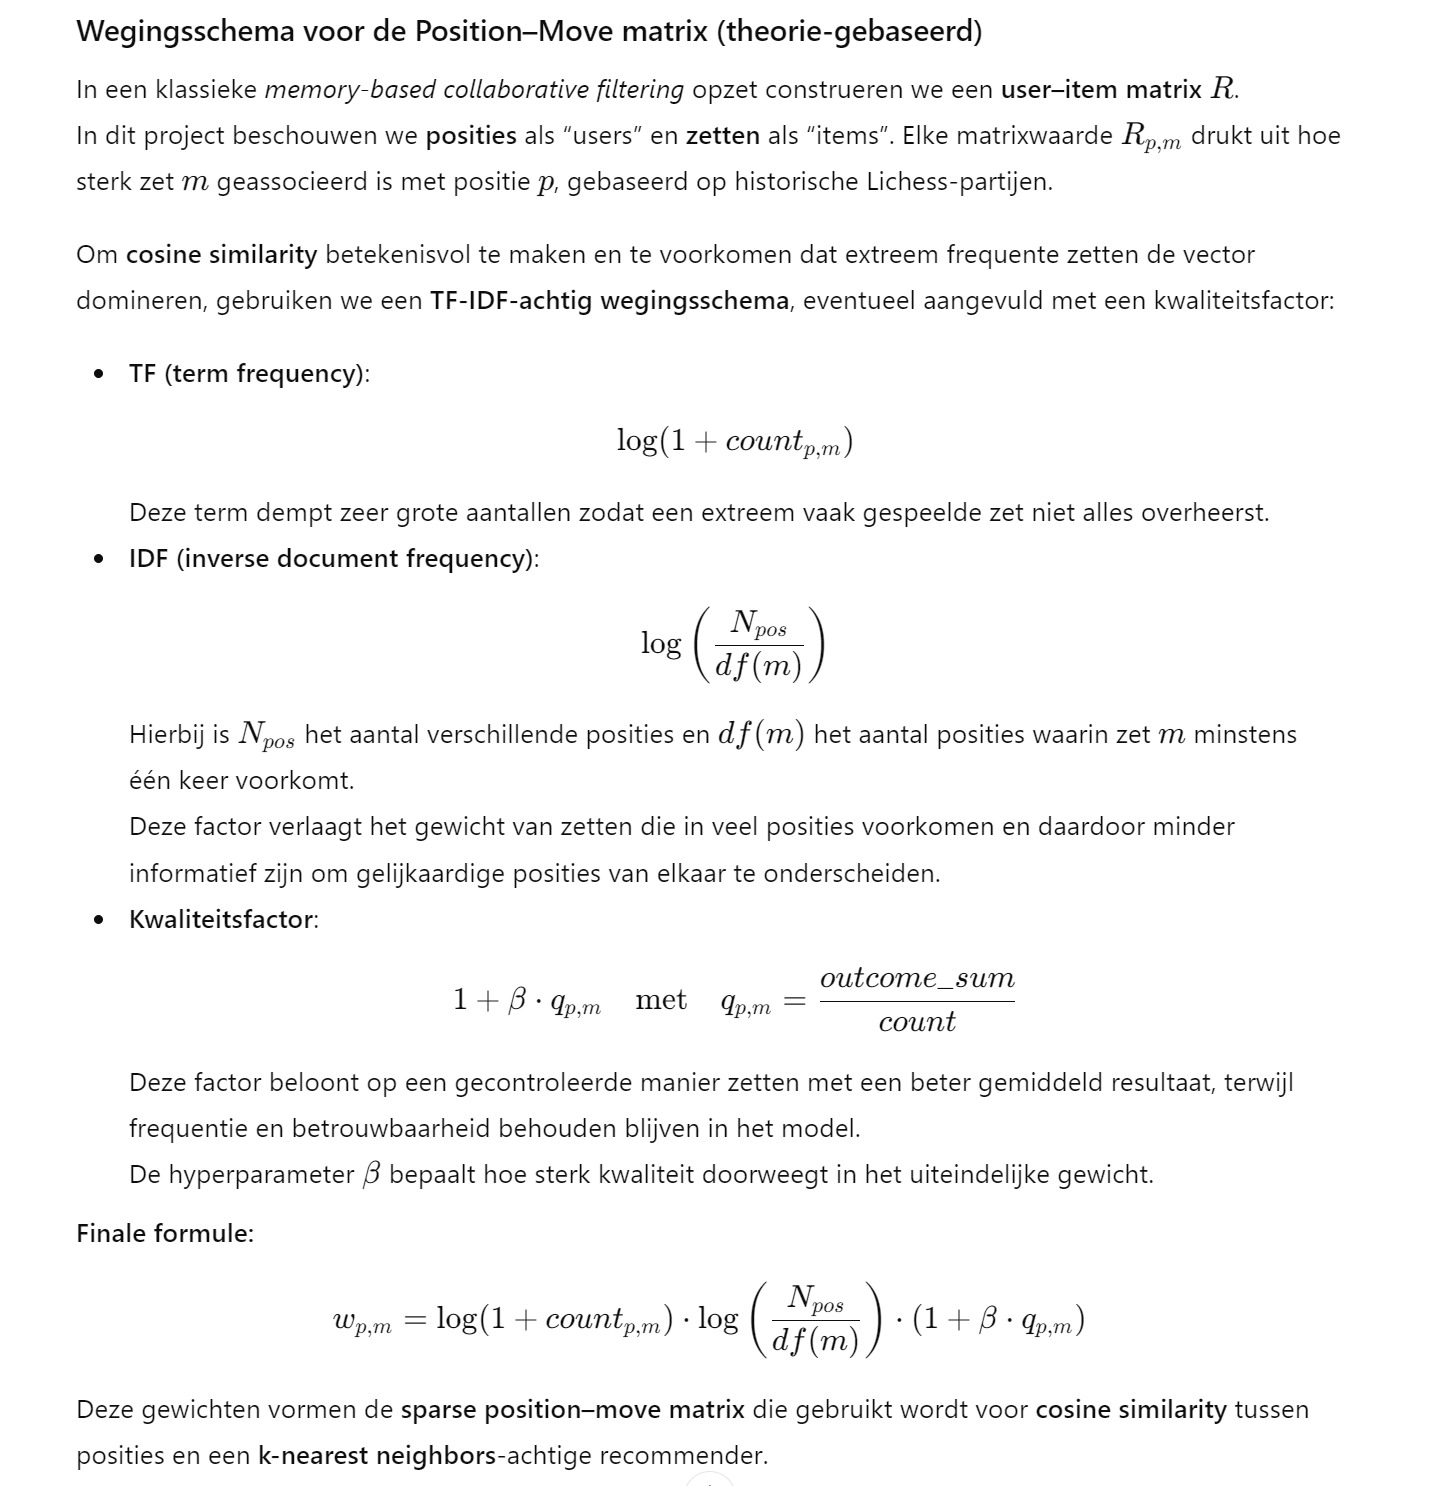

In [14]:
# ============================
# Compute weights (w) for a Position–Move matrix
# using TF-IDF (+ optional quality factor) in a memory-safe way.
# Works well in Google Colab Free because DuckDB reads Parquet out-of-core.
# ============================

!pip -q install duckdb

import duckdb
from pathlib import Path

# ----------------------------
# USER SETTINGS (adjust paths if needed)
# ----------------------------
TABLE_A_MIN10_PATH = str(A_FINAL_DIR / "tableA_min10.parquet")
OUT_WITH_W_PATH    = str(A_FINAL_DIR / "tableA_min10_with_w.parquet")

# Weighting hyperparameter:
# beta controls how much the average outcome influences the weight.
# 0.0 => pure TF-IDF, 0.3..0.7 recommended.
BETA = 0.3

# DuckDB temp folder (important for stability on big files):
# Prefer local disk (/content) over Google Drive.
DUCKDB_TEMP_DIR = "/content/duckdb_tmp"
Path(DUCKDB_TEMP_DIR).mkdir(parents=True, exist_ok=True)

print("=== Step 0/4: Setup DuckDB ===")
con = duckdb.connect(database=":memory:")

# Limit memory so DuckDB spills to disk instead of crashing RAM
con.execute("PRAGMA memory_limit='3GB'")
con.execute(f"PRAGMA temp_directory='{DUCKDB_TEMP_DIR}'")
con.execute("PRAGMA threads=4")  # adjust if you want (2-4 is ok on Colab)

# Optional: Show a bit more info in DuckDB logs (not always necessary)
# con.execute("PRAGMA enable_profiling='json'")

print("Input:", TABLE_A_MIN10_PATH)
print("Output:", OUT_WITH_W_PATH)
print("beta:", BETA)
print()

# ----------------------------
# Step 1: Count how many unique positions exist (N_pos)
# and how many positions each move appears in (df(move)).
# This is needed for IDF: log(N_pos / df(move))
# ----------------------------
print("=== Step 1/4: Compute N_pos and df(move) for IDF ===")

# Create a view on the Parquet file (no full load into memory)
con.execute(f"""
CREATE OR REPLACE VIEW A AS
SELECT
  pos_key,
  next_move_uci,
  count,
  outcome_sum,
  castling_mask,
  elo_sum,
  elo_outcome_sum
FROM read_parquet('{TABLE_A_MIN10_PATH}');
""")

# N_pos = number of distinct positions
N_pos = con.execute("SELECT COUNT(DISTINCT pos_key) FROM A;").fetchone()[0]
print("N_pos (distinct positions) =", N_pos)

# df(move) = number of distinct positions in which a move appears
# We store it as a temporary table for fast join later.
con.execute("""
CREATE OR REPLACE TEMP TABLE df_move AS
SELECT
  next_move_uci,
  COUNT(DISTINCT pos_key) AS df
FROM A
GROUP BY next_move_uci;
""")

df_count = con.execute("SELECT COUNT(*) FROM df_move;").fetchone()[0]
print("Unique moves (df_move rows) =", df_count)
print()

# ----------------------------
# Step 2: Compute weights (w)
# Formula (theory-aligned):
#   TF  = log(1 + count)
#   q   = outcome_sum / count
#   IDF = log(N_pos / df(move))
#   w   = TF * IDF * (1 + beta*q)
#
# Notes:
# - log is natural log in DuckDB.
# - We guard against df=0 (shouldn't happen) and count=0 (shouldn't happen).
# - We also clamp the quality factor to a safe positive range to avoid negative weights.
#   (If your outcome encoding could ever be negative, this prevents issues.)
# ----------------------------
print("=== Step 2/4: Build output table with weight column w ===")

# We'll write directly to Parquet (out-of-core).
# Progress: we print milestones before/after the heavy query.

# Choose a small clamp range for the quality multiplier.
# If q is in [0,1], then (1 + beta*q) is already safe.
# But we keep a clamp in case of unexpected encoding.
QUALITY_MIN = 0.10
QUALITY_MAX = 3.00

query = f"""
COPY (
  SELECT
    a.pos_key,
    a.castling_mask,
    a.next_move_uci,
    a.count,
    a.elo_sum,
    a.outcome_sum,
    a.elo_outcome_sum,

    -- Average outcome per observation (quality signal)
    CAST(a.outcome_sum AS DOUBLE) / NULLIF(a.count, 0) AS q,

    -- TF: damped frequency
    LN(1.0 + a.count) AS tf,

    -- IDF: downweight moves that appear in many positions
    LN({N_pos} * 1.0 / NULLIF(d.df, 0)) AS idf,

    -- Final weight w
    (
      LN(1.0 + a.count)
      * LN({N_pos} * 1.0 / NULLIF(d.df, 0))
      * LEAST({QUALITY_MAX}, GREATEST({QUALITY_MIN}, (1.0 + {BETA} * (CAST(a.outcome_sum AS DOUBLE) / NULLIF(a.count, 0)))))
    ) AS w

  FROM A a
  JOIN df_move d
    ON a.next_move_uci = d.next_move_uci
)
TO '{OUT_WITH_W_PATH}' (FORMAT PARQUET, COMPRESSION 'SNAPPY');
"""

print("Running DuckDB query (this is the heavy part)...")
con.execute(query)
print("Done writing:", OUT_WITH_W_PATH)
print()

# ----------------------------
# Step 3: Quick sanity checks
# ----------------------------
print("=== Step 3/4: Sanity checks ===")

# Check a few rows + basic stats
row_count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{OUT_WITH_W_PATH}');").fetchone()[0]
print("Rows in output =", row_count)

stats = con.execute(f"""
SELECT
  MIN(w) AS min_w,
  MAX(w) AS max_w,
  AVG(w) AS avg_w
FROM read_parquet('{OUT_WITH_W_PATH}');
""").fetchone()

print("w stats:", {"min": stats[0], "max": stats[1], "avg": stats[2]})
print()

print("=== Step 4/4: Cleanup ===")
con.close()
print("All done ✅")

=== Step 0/4: Setup DuckDB ===
Input: /content/drive/MyDrive/Howest_project/derived_data/agg_position_move/tableA_min10.parquet
Output: /content/drive/MyDrive/Howest_project/derived_data/agg_position_move/tableA_min10_with_w.parquet
beta: 0.3

=== Step 1/4: Compute N_pos and df(move) for IDF ===
N_pos (distinct positions) = 360527
Unique moves (df_move rows) = 1490

=== Step 2/4: Build output table with weight column w ===
Running DuckDB query (this is the heavy part)...
Done writing: /content/drive/MyDrive/Howest_project/derived_data/agg_position_move/tableA_min10_with_w.parquet

=== Step 3/4: Sanity checks ===
Rows in output = 546927
w stats: {'min': 7.081202356405619, 'max': 91.31961693848476, 'avg': 18.963132994136394}

=== Step 4/4: Cleanup ===
All done ✅


In [15]:
print("\nTable A with weights")
pf = pq.ParquetFile(A_FINAL_DIR / "tableA_min10_with_w.parquet")
table = pf.read_row_group(0)
display(table.to_pandas().head(10))

table.shape


Table A with weights


,pos_key,castling_mask,next_move_uci,count,elo_sum,outcome_sum,elo_outcome_sum,q,tf,idf,w
0,rnbqkbnr/ppp1pppp/3p4/4P3/3P1P2/8/PPP3PP/RNBQK...,KQkq,c7c5,11,26374.0,3.0,3.625250,0.272727,2.484907,4.032363,10.839868
1,rnbqkb1r/ppp1pp2/6pp/8/4P2P/2P2N2/P2P1PP1/R1BQ...,KQkq,f8g7,13,33543.5,3.0,3.924375,0.230769,2.639057,4.048765,11.424648
2,rn1qkb1r/pbp2ppp/1p1ppn2/8/2PP4/2N2NP1/PP2PP1P...,KQkq,f1g2,13,31431.0,7.5,9.061000,0.576923,2.639057,4.298332,13.306849
3,rnbqk2r/pp2p1bp/3ppnp1/2P3N1/5P2/2N5/PPP3PP/R1...,KQkq,e8g8,12,28771.5,4.5,5.445125,0.375000,2.564949,2.935786,8.377285
4,r2qk2r/pp1n1ppp/2pbpn2/5b2/2PP4/2N2N2/PP2BPPP/...,kq,h2h3,17,42159.5,7.5,9.285875,0.441176,2.890372,3.939231,12.892792
5,r1bq1rk1/pp3pbp/2n1pnp1/2pp4/4P3/3P1NP1/PPPNQP...,-,b7b5,17,42166.5,6.0,7.584000,0.352941,2.890372,4.469532,14.286461
6,2r1kbnr/pp1b1ppp/1qn1p3/2ppP3/3P4/2P3PB/PP2NP1...,KQk,e1g1,14,33664.5,10.0,12.021750,0.714286,2.708050,2.849685,9.370754
7,rn1qk2r/pp2bpp1/2p1pn1p/3p1b2/5B2/2NP1NP1/PPP1...,kq,f1e1,11,26387.0,3.0,3.647375,0.272727,2.484907,4.517910,12.145124
8,r1bq1k1r/pp3pp1/2n1p2p/2PpP3/6Q1/P1nBBN2/2P2PP...,KQ,f7f5,22,54302.0,13.5,16.536125,0.613636,3.135494,5.166318,19.181042
9,3q1rk1/5ppp/p3p3/1prn4/4b3/5NP1/PP1QPPBP/R4RK1 w,-,a1c1,12,28950.5,9.0,10.868750,0.750000,2.564949,5.254701,16.510600


(122880, 11)

# Engine

In [ ]:
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pandas as pd
from pathlib import Path
import random
import math


# ---- CONFIG ----
DATASET_DIR = Path("/content/drive/MyDrive/Howest_project/derived_data/chess_v1_dataset")

# Retrieval settings
MIN_MATCHES = 200         # minimum aantal voorbeelden om stabiel te ranken
PLY_WINDOW = 20           # ply filter window (±20)
PLY_WINDOW_FALLBACK = 40  # verruim naar ±40 als te weinig matches
MAX_ROWS_TO_RANK = 200_000  # safety cap: neem max zoveel rows mee in ranking (random sample)

# Ranking settings
ELO_REF = 2000.0          # normalisatie voor elo-gewicht
IMDB_C = 20.0             # shrinkage strength

# -----------------

def time_control_bucket(tc: str | None) -> str:
    """
    Map lichess TimeControl like '300+0' to bucket: bullet/blitz/rapid/classical/unknown
    Uses base time only (seconds). This is a heuristic.
    """
    if not tc or tc == "-":
        return "unknown"
    try:
        base = int(tc.split("+")[0])
    except:
        return "unknown"
    if base < 180:
        return "bullet"
    if base < 600:
        return "blitz"
    if base < 1800:
        return "rapid"
    return "classical"

def parse_history_tokens(history_last6_uci: str) -> list[str]:
    toks = history_last6_uci.split("|") if history_last6_uci else []
    # ensure length 6 if possible
    return toks

def history_key(history_last6_uci: str, n_tokens: int) -> str:
    """
    Get last n_tokens from last6 string.
    Example: last6 = A|B|C|D|E|F
      n=4 -> C|D|E|F
      n=2 -> E|F
    """
    toks = parse_history_tokens(history_last6_uci)
    if len(toks) == 0:
        return ""
    return "|".join(toks[-n_tokens:])

def outcome_from_perspective(result: str | None, side_to_move: str) -> float:
    """
    Convert game Result to outcome score from perspective of the player to move at this position.
    win=1.0, draw=0.5, loss=0.0
    """
    if result not in ("1-0", "0-1", "1/2-1/2"):
        return 0.5  # unknown -> neutral
    if result == "1/2-1/2":
        return 0.5
    white_won = (result == "1-0")
    if side_to_move == "w":
        return 1.0 if white_won else 0.0
    else:
        return 0.0 if white_won else 1.0

def build_filter_expr(query: dict, level: str, ply_window: int, use_tc_bucket: bool = True):
    """
    Build a pyarrow expression for a retrieval level.
    level in:
      - 'fen_hist_tc'  : fen + history_last6 + tc_bucket
      - 'fen_hist'     : fen + history_last6
      - 'fen_last4'    : fen + last4
      - 'fen_last2'    : fen + last2
      - 'fen_only'     : fen only
    plus: ply filter-only window
    """
    fen = query["fen_norm"]
    side = query["side_to_move"]
    ply = query["ply"]
    tc = query.get("time_control")
    tc_bucket_q = time_control_bucket(tc)
    hist6 = query["history_last6_uci"]
    last4 = history_key(hist6, 4)
    last2 = history_key(hist6, 2)

    expr = (pc.field("fen_norm") == fen) & (pc.field("side_to_move") == side)

    # ply filter-only
    expr = expr & (pc.abs(pc.field("ply") - ply) <= ply_window)

    if level == "fen_hist_tc":
        if use_tc_bucket:
            expr = expr & (pc.equal(pc.scalar(tc_bucket_q), pc.scalar(tc_bucket_q)))  # no-op safeguard
            # We don't have bucket stored; compare by computed bucket is not possible in arrow expr.
            # Fallback: exact time_control match instead (V1 has time_control string).
            expr = expr & (pc.field("time_control") == (tc if tc else ""))
        else:
            expr = expr & (pc.field("time_control") == (tc if tc else ""))
        expr = expr & (pc.field("history_last6_uci") == hist6)

    elif level == "fen_hist":
        expr = expr & (pc.field("history_last6_uci") == hist6)

    elif level == "fen_last4":
        # Can't compute last4 inside Arrow expr; we’ll do a wider scan and filter in pandas later.
        # Here: only fen + ply; last4 filter applied post-read.
        pass

    elif level == "fen_last2":
        # Same: post-filter
        pass

    elif level == "fen_only":
        pass

    else:
        raise ValueError("Unknown level")

    return expr, last4, last2

def scan_matches(dataset, expr, columns):
    """
    Return pandas df for rows matching expr.
    """
    table = dataset.to_table(columns=columns, filter=expr)
    if table.num_rows == 0:
        return pd.DataFrame(columns=columns)
    return table.to_pandas()

def rank_top3(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rank moves using:
      - support = count
      - elo_weighted_support = sum(w_elo)
      - move_success = avg(outcome, weighted by w_elo)
      - imdb_shrunk_score: shrink move_success toward global mean using support
    """
    if df.empty:
        return df

    # compute weights and outcomes
    avg_elo = (df["white_elo"].fillna(ELO_REF) + df["black_elo"].fillna(ELO_REF)) / 2.0
    w_elo = (avg_elo / ELO_REF).clip(lower=0.5, upper=2.0)  # keep bounded
    outcome = [
        outcome_from_perspective(r, s) for r, s in zip(df["result"].tolist(), df["side_to_move"].tolist())
    ]

    df = df.copy()
    df["w_elo"] = w_elo
    df["outcome"] = outcome

    # global mean outcome in this match-set (weighted)
    mu = (df["outcome"] * df["w_elo"]).sum() / max(1e-9, df["w_elo"].sum())

    grouped = df.groupby("next_move_uci").agg(
        support=("next_move_uci", "size"),
        elo_support=("w_elo", "sum"),
        weighted_outcome_sum=("outcome", lambda x: 0.0),  # placeholder
    )

    # compute weighted outcome per move
    # (need weights aligned; easier explicit loop)
    rows = []
    for mv, g in df.groupby("next_move_uci"):
        sup = len(g)
        elo_sup = g["w_elo"].sum()
        move_success = (g["outcome"] * g["w_elo"]).sum() / max(1e-9, elo_sup)

        # IMDB-like shrinkage with v = support (or elo_support). Here we use elo_support as "confidence".
        v = float(elo_sup)
        imdb = (v / (v + IMDB_C)) * move_success + (IMDB_C / (v + IMDB_C)) * mu

        rows.append({
            "next_move_uci": mv,
            "support": sup,
            "elo_support": round(elo_sup, 2),
            "move_success": round(move_success, 4),
            "imdb_shrunk_score": round(imdb, 4),
        })

    out = pd.DataFrame(rows).sort_values(
        by=["imdb_shrunk_score", "elo_support", "support"],
        ascending=[False, False, False]
    ).head(3).reset_index(drop=True)

    return out

def recommend_next_moves(query: dict) -> dict:
    """
    query keys required:
      fen_norm, history_last6_uci, ply, side_to_move, time_control
    Returns dict with:
      - level used
      - matches_count
      - top3 dataframe
    """
    dataset = ds.dataset(DATASET_DIR, format="parquet")

    cols = ["fen_norm", "history_last6_uci", "next_move_uci", "ply", "side_to_move",
            "white_elo", "black_elo", "time_control", "result"]

    levels = ["fen_hist_tc", "fen_hist", "fen_last4", "fen_last2", "fen_only"]

    # Try ply window then fallback window then no filter (last resort)
    ply_windows = [PLY_WINDOW, PLY_WINDOW_FALLBACK, None]

    best = None

    for pw in ply_windows:
        print(f"\nAttempting with ply_window: {pw}")
        for level in levels:
            print(f"  Trying level: {level}")
            if pw is None:
                # no ply filter
                ply_expr = (pc.field("fen_norm") == query["fen_norm"]) & (pc.field("side_to_move") == query["side_to_move"])
                expr = ply_expr
                last4 = history_key(query["history_last6_uci"], 4)
                last2 = history_key(query["history_last6_uci"], 2)
            else:
                expr, last4, last2 = build_filter_expr(query, level, pw)

            # For last4/last2 levels we need a broader fetch then post-filter in pandas
            if level in ("fen_last4", "fen_last2"):
                # fetch fen + ply-filter (if enabled), then filter last4/last2 in pandas
                print(f"    Scanning matches for level {level} (pre-filter)")
                df = scan_matches(dataset, expr, cols)
                if df.empty:
                    print(f"    No matches found for level {level} (pre-filter)")
                    continue
                if level == "fen_last4":
                    key = last4
                    df = df[df["history_last6_uci"].apply(lambda h: history_key(h, 4) == key)]
                else:
                    key = last2
                    df = df[df["history_last6_uci"].apply(lambda h: history_key(h, 2) == key)]
                print(f"    Matches after history key filter: {len(df)}")
            else:
                print(f"    Scanning matches for level {level}")
                df = scan_matches(dataset, expr, cols)

            n = len(df)
            print(f"    Found {n} matches.")
            if n == 0:
                continue

            # optional cap for speed (sample)
            if n > MAX_ROWS_TO_RANK:
                print(f"    Sampling {MAX_ROWS_TO_RANK} rows from {n} matches.")
                df = df.sample(MAX_ROWS_TO_RANK, random_state=42)
                n = len(df)

            # stop when enough examples
            if n >= MIN_MATCHES or level == "fen_only":
                print(f"    Ranking top 3 moves for {n} matches.")
                top3 = rank_top3(df)
                print(f"    Returning results for level: {level}, ply_window: {pw}")
                return {
                    "used_level": level,
                    "ply_window": pw,
                    "matches_count": n,
                    "top3": top3
                }

    print("\nNo sufficient matches found for any level/ply_window combination.")
    return {
        "used_level": None,
        "ply_window": None,
        "matches_count": 0,
        "top3": pd.DataFrame(columns=["next_move_uci","support","elo_support","move_success","imdb_shrunk_score"])
    }

# --- Helper: pick a random row as a query (easy way to test) ---
def random_query_from_dataset():
    dataset = ds.dataset(DATASET_DIR, format="parquet")
    # grab a small sample from the dataset (manual work-around instead of using the limit param which is only availablle in pyarrow v6.0.0)
    columns_to_fetch = ["fen_norm", "history_last6_uci", "ply", "side_to_move", "time_control"]
    scanner = dataset.scanner(columns=columns_to_fetch)

    all_rows = []
    rows_collected = 0
    max_rows_to_collect = 5000 # The original limit

    for batch in scanner.to_batches():
        all_rows.append(batch.to_pandas())
        rows_collected += len(batch)
        if rows_collected >= max_rows_to_collect:
            break

    if not all_rows:
        raise ValueError("No data collected from the dataset.")

    sample_df = pd.concat(all_rows, ignore_index=True)
    sample_df = sample_df.head(max_rows_to_collect)

    if sample_df.empty:
        raise ValueError("Sampled DataFrame is empty. Check dataset or sampling logic.")

    row = sample_df.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
    return {
        "fen_norm": row["fen_norm"],
        "history_last6_uci": row["history_last6_uci"],
        "ply": int(row["ply"]),
        "side_to_move": row["side_to_move"],
        "time_control": row["time_control"]
    }


Demo run:

In [ ]:
# --- DEMO RUN ---
q = random_query_from_dataset()
print("QUERY:", q)

res = recommend_next_moves(q)
print("\nUsed level:", res["used_level"], "| ply_window:", res["ply_window"], "| matches:", res["matches_count"])
display(res["top3"])

QUERY: {'fen_norm': 'r3r1k1/5pp1/2pb3p/3p3N/N2P1P1n/3BP2b/2Q3qP/1R3RK1 w - -', 'history_last6_uci': 'c3a4|c8h3|g3h5|f6g5|f2f4|g5g2', 'ply': 42, 'side_to_move': 'w', 'time_control': '180+1'}

Attempting with ply_window: 20
  Trying level: fen_hist_tc
    Scanning matches for level fen_hist_tc
    Found 1 matches.
  Trying level: fen_hist
    Scanning matches for level fen_hist
    Found 1 matches.
  Trying level: fen_last4
    Scanning matches for level fen_last4 (pre-filter)
    Matches after history key filter: 1
    Found 1 matches.
  Trying level: fen_last2
    Scanning matches for level fen_last2 (pre-filter)
    Matches after history key filter: 1
    Found 1 matches.
  Trying level: fen_only
    Scanning matches for level fen_only
    Found 1 matches.
    Ranking top 3 moves for 1 matches.
    Returning results for level: fen_only, ply_window: 20

Used level: fen_only | ply_window: 20 | matches: 1


,next_move_uci,support,elo_support,move_success,imdb_shrunk_score
0,c2g2,1,1.22,0.0,0.0


# **Demographic Filtering** -
   Before getting started with this  -
* we need a metric to score or rate a book
* Calculate the score for every book
* Sort the scores and recommend the best rated book to the users.

We can use the average ratings of the book as the score but using this won't be fair enough since a book with 4.5 average rating and only 3 votes cannot be considered better than the book with 3.9 as as average rating but 40 votes.
So, I'll be using IMDB's weighted rating (wr) which is given as :-

![](https://image.ibb.co/jYWZp9/wr.png)
where,
* v is the number of votes for the movie;
* m is the minimum votes required to be listed in the chart;
* R is the average rating of the movie; And
* C is the mean vote across the whole report

Now apply this on the books dataset instead of on movies.

We already have v(**vote_count**) and R (**vote_average**) and C can be calculated as

In [ ]:
# Calculate C

C= df_bookinfo['vote_average'].mean()
C

4.2620630054048565

So, the mean rating for all the books is approx 4.3 on a scale of 5.The next step is to determine an appropriate value for m, the minimum votes required to be listed in the chart. We will use 90th percentile as our cutoff. In other words, for a book to feature in the charts, it must have more votes than at least 90% of the book in the list.

In [ ]:
# calculate m

m= df_bookinfo['vote_count'].quantile(0.9)
m

24.0

Now, we can filter out the books that qualify for the chart

In [ ]:
# filter out the books that qualify for the chart

q_books = df_bookinfo.copy().loc[df_bookinfo['vote_count'] >= m]
q_books.shape

(2025, 12)

We see that there are 2025 books which qualify to be in this list. Now, we need to calculate our metric for each qualified book. To do this, we will define a function, **weighted_rating()** and define a new feature **score**, of which we'll calculate the value by applying this function to our DataFrame of qualified books:

In [ ]:
# Construct a weighted_rating function that calculates the metric for each qualified book

def weighted_rating(x, m=m, C=C):
    v = x['vote_count']
    R = x['vote_average']
    # Calculation based on the IMDB formula
    return (v/(v+m) * R) + (m/(m+v) * C)

In [ ]:
# Define a new feature 'score' and calculate its value with `weighted_rating()`

q_books['score'] = q_books.apply(weighted_rating, axis=1)

Finally, let's sort the DataFrame based on the score feature and output the title, vote count, vote average and weighted rating or score of the top 10 books.

In [ ]:
#Sort books based on score calculated above and print the top 10 books

q_books = q_books.sort_values('score', ascending=False)

#Print the top 10 books
q_books[['Title', 'vote_count', 'vote_average', 'score']].head(10)

,Title,vote_count,vote_average,score
4990,Betty Crocker's cooky book,233,4.909871,4.849376
9717,Little Britches,192,4.916667,4.843933
19150,The Valley of Vision: a Collection of Puritan ...,179,4.921788,4.843791
11987,Mossflower,313,4.872204,4.828752
15229,The Synonym Finder,307,4.863192,4.819606
4670,Angelique: The Marquise of the Angels,87,4.954023,4.804410
13705,The Family Nobody Wanted,140,4.885714,4.794448
12226,Anne of the Island,249,4.843373,4.792269
16333,"The Happy Hollisters (The Happy Hollisters, No...",107,4.906542,4.788470
12043,"Why revival tarries,",69,4.971014,4.788059


Hurray! We have made our first(though very basic) recommender.
Under the **Trending Now** tab of these systems we find books that are very popular and they can just be obtained by sorting the dataset by the popularity column.

In [ ]:
# Print the five most popular books based on the review/time column in df_ratings. Take all reviews into account of the last month in the dataset.

# Convert 'review/time' to datetime objects
df_ratings['review/time'] = pd.to_datetime(df_ratings['review/time'], unit='s')

# Filter reviews from the last month
last_month = df_ratings['review/time'].max() - pd.DateOffset(months=1)
recent_reviews = df_ratings[df_ratings['review/time'] >= last_month]

# Group by title and count the number of recent reviews
popular_books = recent_reviews.groupby('Title')['review/time'].count().sort_values(ascending=False)

# Get the top 5 most popular books
top_5_books = popular_books.head(5)

top_5_books

,review/time
Title,
Pride and Prejudice,1657
The Hobbit,1624
Wuthering Heights,550
The Hobbit There and Back Again,356
"The Hobbitt, or there and back again; illustrated by the author.",348


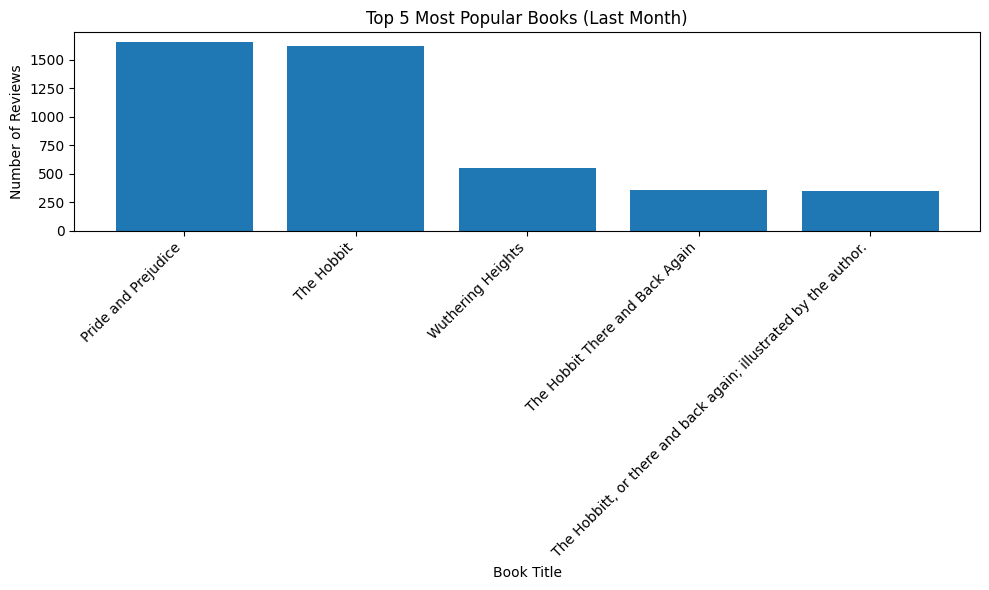

In [ ]:
# Make a bar plot of the 5 most popular books

# Create the bar plot
plt.figure(figsize=(10, 6))
plt.bar(top_5_books.index, top_5_books.values)
plt.xlabel("Book Title")
plt.ylabel("Number of Reviews")
plt.title("Top 5 Most Popular Books (Last Month)")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

Now something to keep in mind is that these demographic recommender provide a general chart of recommended books to all the users. They are not sensitive to the interests and tastes of a particular user.
This is when we move on to a more refined system-  Content Based Filtering.

# **Content Based Filtering**
In this recommender system the content of the book is used to find its similarity with other books. Then the books that are most likely to be similar are recommended.

## **Plot description based Recommender**

We will compute pairwise similarity scores for all books based on their plot descriptions and recommend books based on that similarity score. The plot description is given in the **overview** feature of our dataset.
Let's take a look at the data. ..

In [ ]:
# Display the first five rows of the 'description' column in bookinfo

df_bookinfo['description'].head(5)

,description
0,NaN
1,Philip Nel takes a fascinating look into the k...
2,This resource includes twelve principles in un...
3,Julia Thomas finds her life spinning out of co...
4,NaN


For any of you who has done even a  bit of text processing before knows we need to convert the word vector of each overview.
Now we'll compute Term Frequency-Inverse Document Frequency (TF-IDF) vectors for each overview.

Now if you are wondering what is term frequency , it is the relative frequency of a word in a document and is given as
   **(term instances/total instances)**.
Inverse Document Frequency is the relative count of documents containing the term is given as
**log(number of documents/documents with term)**
The overall importance of each word to the documents in which they appear is equal to **TF * IDF**

This will give you a matrix where each column represents a word in the overview vocabulary (all the words that appear in at least one document) and each row represents a book, as before.This is done to reduce the importance of words that occur frequently in plot overviews and therefore, their significance in computing the final similarity score.

Fortunately, scikit-learn gives you a built-in TfIdfVectorizer class that produces the TF-IDF matrix in a couple of lines. That's great, isn't it?

In [ ]:
#Define a TF-IDF Vectorizer Object. Remove all english stop words such as 'the', 'a'

tfidf = TfidfVectorizer(stop_words='english')

#Replace NaN with an empty string
df_bookinfo['description'] = df_bookinfo['description'].fillna('')

#Construct the required TF-IDF matrix by fitting and transforming the data
tfidf_matrix = tfidf.fit_transform(df_bookinfo['description'])

#Output the shape of tfidf_matrix
tfidf_matrix.shape

(20000, 68748)

We see that over 68000 different words were used to describe the more than 20000 selected books in our dataset.

With this matrix in hand, we can now compute a similarity score. There are several candidates for this; such as the euclidean, the Pearson and the [cosine similarity scores](https://en.wikipedia.org/wiki/Cosine_similarity). There is no right answer to which score is the best. Different scores work well in different scenarios and it is often a good idea to experiment with different metrics.

We will be using the cosine similarity to calculate a numeric quantity that denotes the similarity between two books. We use the cosine similarity score since it is independent of magnitude and is relatively easy and fast to calculate. Mathematically, it is defined as follows:
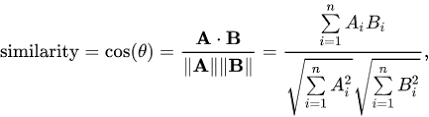

Since we have used the TF-IDF vectorizer, calculating the dot product will directly give us the cosine similarity score. Therefore, we will use sklearn's **linear_kernel()** instead of cosine_similarities() since it is faster.

In [ ]:
# Compute the cosine similarity matrix

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

We are going to define a function that takes in a book title as an input and outputs a list of the 10 most similar books. Firstly, for this, we need a reverse mapping of book titles and DataFrame indices. In other words, we need a mechanism to identify the index of a book in our metadata DataFrame, given its title.

In [ ]:
#Construct a reverse map of indices and book titles

indices = pd.Series(df_bookinfo.index, index=df_bookinfo['Title']).drop_duplicates()

We are now in a good position to define our recommendation function. These are the following steps we'll follow :-
* Get the index of the book given its title.
* Get the list of cosine similarity scores for that particular book with all books. Convert it into a list of tuples where the first element is its position and the second is the similarity score.
* Sort the aforementioned list of tuples based on the similarity scores; that is, the second element.
* Get the top 10 elements of this list. Ignore the first element as it refers to self (the book most similar to a particular book is the book itself).
* Return the titles corresponding to the indices of the top elements.

In [ ]:
# Function that takes in book title as input and outputs most similar books

def get_recommendations(title, cosine_sim):
    # Get the index of the book that matches the title
    idx = indices[title]

    # Get the pairwsie similarity scores of all books with that book
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the books based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar books
    sim_scores = sim_scores[1:11]

    # Get the book indices
    book_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar books
    return df_bookinfo['Title'].iloc[book_indices]

In [ ]:
get_recommendations('The Battleship Bismarck', cosine_sim)

,Title
18402,The last nine days of the Bismarck
6849,Admirals in Collision
17238,Band of Brothers: Boy Seamen in the Royal Navy...
6133,Sharpe's Trafalgar (Richard Sharpe's Adventure...
9557,Cunard: 150 Glorious Years
8110,The Letter of Marque (Aubrey-Maturin)
14325,Distant Gunfire
476,United States Navy Aircraft Since 1911
10193,"Germany's high sea fleet in the world war,"
14764,Captain Kilburnie


In [ ]:
get_recommendations('Wonderful Worship in Smaller Churches', cosine_sim)

,Title
17660,Classic Children's Prayers (Little Prayer Series)
3918,"The Ultimate Priority: John Macarthur, Jr. on ..."
13467,For the Audience of One: Worshiping the One an...
13872,"Psalms In Worship, The (Lillenas Drama)"
3230,The Worship Leader's Handbook: Practical Answe...
7926,"When We Gather, Revised Edition: A Book of Pra..."
10186,The Cokesbury Worship Hymnal
9910,Whatever Happened to Worship: A Call To True W...
16142,Catholics
14377,As It Is in Heaven


## **Authors, publisher, published date and Genres Based Recommender**
It goes without saying that the quality of our recommender would be increased with the usage of better metadata. That is exactly what we are going to do in this section. We are going to build a recommender based on the following metadata: the authors, the publisher, the published date and related genres.

We need to convert the data into safe and useable features first.
* Authors and categories are a list of strings -> convert stringified list to a list
* Publisher is a string -> ok
* published date is a date -> this has to be converted to a float and normalised

In [ ]:
# Convert stringified list to a list

features = ['authors', 'categories']
for feature in features:
    df_bookinfo[feature] = df_bookinfo[feature].apply(lambda x: x if pd.isnull(x) else literal_eval(x))

In [ ]:
# Convert all values in publishedDate to a string of the year. Some entries are in 'year' format, some in 'year-month-day' format
# If values are Nan, return Nan

# Function to extract the year from the publishedDate
def extract_year(date_str):
    if isinstance(date_str, str):
        if '-' in date_str:
            return date_str.split('-')[0]  # Extract the year part
        else:
            return date_str  # Already in year format
    else:
        return np.nan  # Handle missing or non-string values


# Apply the function to the 'publishedDate' column
# Assuming 'publishedDate' is the correct column name in your dataframe
df_bookinfo['published_year'] = df_bookinfo['publishedDate'].apply(extract_year)

In [ ]:
# Print the new features of the first 5 books

df_bookinfo[['Title', 'authors', 'publisher', 'published_year', 'categories']].head(5)

,Title,authors,publisher,published_year,categories
0,Its Only Art If Its Well Hung!,[Julie Strain],NaN,1996,[Comics & Graphic Novels]
1,Dr. Seuss: American Icon,[Philip Nel],A&C Black,2005,[Biography & Autobiography]
2,Wonderful Worship in Smaller Churches,[David R. Ray],NaN,2000,[Religion]
3,Whispers of the Wicked Saints,[Veronica Haddon],iUniverse,2005,[Fiction]
4,"Nation Dance: Religion, Identity and Cultural ...",[Edward Long],NaN,2003,NaN


The next step would be to convert the names and keyword instances into lowercase and strip all the spaces between them. This is done so that our vectorizer doesn't count the Johnny of "Johnny Depp" and "Johnny Galecki" as the same.

In [ ]:
# Function to convert all strings to lower case and strip names of spaces

def clean_data(x):
    if isinstance(x, list):
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        #Check if publisher exists. If not, return empty string
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            return ''

In [ ]:
# Apply clean_data function to your features.

features = ['authors', 'publisher', 'published_year', 'categories']

for feature in features:
    df_bookinfo[feature] = df_bookinfo[feature].apply(clean_data)

We are now in a position to create our "metadata soup", which is a string that contains all the metadata that we want to feed to our vectorizer.

In [ ]:
# Create a metadata soup using the function seen in the demo

def create_soup(x):
    return ' '.join(x['authors']) + ' ' + ' '.join(x['publisher']) + ' ' + x['published_year'] + ' ' + ' '.join(x['categories'])
df_bookinfo['soup'] = df_bookinfo.apply(create_soup, axis=1)

The next steps are the same as what we did with our plot description based recommender. One important difference is that we use the **CountVectorizer()** instead of TF-IDF. This is because we do not want to down-weight the presence of for example an author if he or she has written more books. It doesn't make much intuitive sense.

In [ ]:
# Create the count matrix

count = CountVectorizer(stop_words='english')
count_matrix = count.fit_transform(df_bookinfo['soup'])

In [ ]:
# Compute the Cosine Similarity matrix based on the count_matrix

cosine_sim2 = cosine_similarity(count_matrix, count_matrix)

In [ ]:
# Reset index of our main DataFrame and construct reverse mapping as before

df_bookinfo = df_bookinfo.reset_index()
indices = pd.Series(df_bookinfo.index, index=df_bookinfo['Title'])

We can now reuse our **get_recommendations()** function by passing in the new **cosine_sim2** matrix as your second argument.

In [ ]:
get_recommendations('The Battleship Bismarck', cosine_sim2)

,Title
14,A husband for Kutani
656,Crusade of the Left: The Lincoln battalion in ...
2075,Snorri Sturluson: Ein biografi (Norwegian Edit...
3731,Spirit Song: The Introduction of No-Eyes
4217,Queen of France;: A biography of Marie Antoinette
5935,"Growth in holiness; or, The progress of the sp..."
7750,"The complete memoirs of George Sherston,"
9062,England Under The Tudors
12109,A German Ace Tells Why: From Kaiserdom to Hitl...
12165,"A History of Russia, Central Asia and Mongolia..."


In [ ]:
get_recommendations('Wonderful Worship in Smaller Churches', cosine_sim2)

,Title
1546,A Philadelphia Catholic to King James's Court:...
1730,Searching for an Adequate God: A Dialogue betw...
2395,My Soul Thirsts: An Invitation to Intimacy Wit...
5000,Word pictures in the New Testament
6499,And I Will Dwell in Their Midst: Orthodox Jews...
7059,Raw Faith: Nurturing the Believer in All of Us
9706,Journey to Self-Realization - Collected Talks ...
10544,Reconstructing Catholicism
13181,The Koran
13273,Directions for Communication Discoveries with ...


On first glance, the recommendations look trustworthy. But it is difficult to see whether these recommendations are better than the ones with the first cosine_sim. We need the test methods described in the theory to check this.

# **Collaborative Filtering**

Our content based engine suffers from some severe limitations. It is only capable of suggesting movies which are close to a certain movie. That is, it is not capable of capturing tastes and providing recommendations across genres.

Also, the engine that we built is not really personal in that it doesn't capture the personal tastes and biases of a user. Anyone querying our engine for recommendations based on a movie will receive the same recommendations for that movie, regardless of who she/he is.

Therefore, in this section, we will use a technique called Collaborative Filtering to make recommendations to Movie Watchers.
It is basically of two types:-

*  **User based filtering**-  These systems recommend products to a user that similar users have liked. For measuring the similarity between two users we can either use pearson correlation or cosine similarity.
This filtering technique can be illustrated with an example. In the following matrixes, each row represents a user, while the columns correspond to different movies except the last one which records the similarity between that user and the target user. Each cell represents the rating that the user gives to that movie. Assume user E is the target.
![](https://cdn-images-1.medium.com/max/1000/1*9NBFo4AUQABKfoUOpE3F8Q.png)

Since user A and F do not share any movie ratings in common with user E, their similarities with user E are not defined in Pearson Correlation. Therefore, we only need to consider user B, C, and D. Based on Pearson Correlation, we can compute the following similarity.
![](https://cdn-images-1.medium.com/max/1000/1*jZIMJzKM1hKTFftHfcSxRw.png)

From the above table we can see that user D is very different from user E as the Pearson Correlation between them is negative. He rated Me Before You higher than his rating average, while user E did the opposite. Now, we can start to fill in the blank for the movies that user E has not rated based on other users.
![](https://cdn-images-1.medium.com/max/1000/1*9TC6BrfxYttJwiATFAIFBg.png)

Although computing user-based CF is very simple, it suffers from several problems. One main issue is that users’ preference can change over time. It indicates that precomputing the matrix based on their neighboring users may lead to bad performance. To tackle this problem, we can apply item-based CF.

* **Item Based Collaborative Filtering** - Instead of measuring the similarity between users, the item-based CF recommends items based on their similarity with the items that the target user rated. Likewise, the similarity can be computed with Pearson Correlation or Cosine Similarity. The major difference is that, with item-based collaborative filtering, we fill in the blank vertically, as oppose to the horizontal manner that user-based CF does. The following table shows how to do so for the movie Me Before You.
![](https://cdn-images-1.medium.com/max/1000/1*LqFnWb-cm92HoMYBL840Ew.png)

It successfully avoids the problem posed by dynamic user preference as item-based CF is more static. However, several problems remain for this method. First, the main issue is ***scalability***. The computation grows with both the customer and the product. The worst case complexity is O(mn) with m users and n items. In addition, ***sparsity*** is another concern. Take a look at the above table again. Although there is only one user that rated both Matrix and Titanic rated, the similarity between them is 1. In extreme cases, we can have millions of users and the similarity between two fairly different movies could be very high simply because they have similar rank for the only user who ranked them both.



### **Single Value Decomposition**
One way to handle the scalability and sparsity issue created by CF is to leverage a **latent factor model** to capture the similarity between users and items. Essentially, we want to turn the recommendation problem into an optimization problem. We can view it as how good we are in predicting the rating for items given a user. One common metric is Root Mean Square Error (RMSE). **The lower the RMSE, the better the performance**.

Now talking about latent factor you might be wondering what is it ?It is a broad idea which describes a property or concept that a user or an item have. For instance, for music, latent factor can refer to the genre that the music belongs to. SVD decreases the dimension of the utility matrix by extracting its latent factors. Essentially, we map each user and each item into a latent space with dimension r. Therefore, it helps us better understand the relationship between users and items as they become directly comparable. The below figure illustrates this idea.

![](https://cdn-images-1.medium.com/max/800/1*GUw90kG2ltTd2k_iv3Vo0Q.png)

Now enough said , let's see how to implement this.
Since the dataset we used before did not have userId(which is necessary for collaborative filtering) let's load another dataset. We'll be using the [**Surprise** ](https://surprise.readthedocs.io/en/stable/index.html) library to implement SVD.

In [ ]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp310-cp310-linux_x86_64.whl size=2357274 sha256=8cd1d2ee45dcc5c02fc458ac67bc21c5643ddca5c79fa653ebff73230f39ff89
  Stored in directory: /root/.cache/pip/wheels/4b/3f/df/6acbf0a40397d9bf3ff97f582cc22fb9ce66adde75bc71fd54
Successfully built scikit-surprise


In [ ]:
from surprise import Reader, Dataset, SVD, accuracy
from surprise.model_selection import cross_validate # Import the cross_validate function

reader = Reader()
df_ratings.head()

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,1882931173,Its Only Art If Its Well Hung!,NaN,AVCGYZL8FQQTD,"Jim of Oz ""jim-of-oz""",7/7,4.0,1999-10-23,Nice collection of Julie Strain images,This is only for Julie Strain fans. It's a col...
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,2004-09-21,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
2,0826414346,Dr. Seuss: American Icon,NaN,A3UH4UZ4RSVO82,John Granger,10/11,5.0,2004-03-09,Essential for every personal and Public Library,"If people become the books they read and if ""t..."
3,0826414346,Dr. Seuss: American Icon,NaN,A2MVUWT453QH61,"Roy E. Perry ""amateur philosopher""",7/7,4.0,2004-07-25,Phlip Nel gives silly Seuss a serious treatment,"Theodore Seuss Geisel (1904-1991), aka &quot;D..."
4,0826414346,Dr. Seuss: American Icon,NaN,A22X4XUPKF66MR,"D. H. Richards ""ninthwavestore""",3/3,4.0,2005-02-10,Good academic overview,Philip Nel - Dr. Seuss: American IconThis is b...


In [ ]:
# Apply SVD as seen in the demo, explain the result
# load relevant data

data = Dataset.load_from_df(df_ratings[['User_id', 'Id', 'review/score']], reader)

In [ ]:
# Construct SVD

svd = SVD()
results = cross_validate(svd, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)
# cv=5 specifies 5-fold cross-validation, verbose=True prints results
print(results) # Print the results dictionary to see the evaluation metrics

In [ ]:
# Fit SVD

trainset = data.build_full_trainset()
svd.fit(trainset)

In [ ]:
# Pick user with ID 'A30TK6U7DNS82R' and check it's ratings

df_ratings[df_ratings['User_id'] == 'A30TK6U7DNS82R']

,Id,Title,Price,User_id,profileName,review/helpfulness,review/score,review/time,review/summary,review/text
1,0826414346,Dr. Seuss: American Icon,NaN,A30TK6U7DNS82R,Kevin Killian,10/10,5.0,2004-09-21,Really Enjoyed It,I don't care much for Dr. Seuss but after read...
18827,B000HJR45I,Finnegans Wake,NaN,A30TK6U7DNS82R,Kevin Killian,5/6,5.0,2008-07-25,Mean Girls,"Haven't read FINNEGANS WAKE in many years, pro..."
24972,B0007E2AAM,Cat Among the Pigeons (Red Badge Detective),NaN,A30TK6U7DNS82R,Kevin Killian,2/2,5.0,2004-08-12,On Children She Could Write Nothing False,"I first read this book when I was twelve, abou..."
39810,1886350973,Blue Mound To 161,NaN,A30TK6U7DNS82R,Kevin Killian,4/5,5.0,2005-12-12,Notes from the Underground,"A few years back I began seeing the name of ""G..."
54225,B000GLJF0E,The Adventure of the Murdered Moths and Other ...,NaN,A30TK6U7DNS82R,Kevin Killian,17/17,5.0,2005-08-18,Challenge to the Reader,"The two cousins who wrote as ""Ellery Queen"" we..."
...,...,...,...,...,...,...,...,...,...,...
2991049,1592480527,2002 Complete Guide to Operation Enduring Free...,29.95,A30TK6U7DNS82R,Kevin Killian,1/2,4.0,2005-06-15,A bargain,"Well, it's a bargain of you consider that you ..."
2992643,1582348952,The Insiders (Insiders (Bloomsbury)),8.11,A30TK6U7DNS82R,Kevin Killian,2/4,3.0,2004-09-05,Advice from a Style Guru,Cecily Von Ziegesar has given this book an ent...
2994019,0060541490,Sexy,NaN,A30TK6U7DNS82R,Kevin Killian,2/3,4.0,2006-01-01,Tea And Sympathy Redux,"Darren Flynn has a problem, little voices are ..."
2994123,B000GLP2NI,The Clocks,NaN,A30TK6U7DNS82R,Kevin Killian,3/4,5.0,2006-02-20,Tick Tock,Christie's longest book (except for the non-my...


In [ ]:
# Check the estimated rating of the user with ID 'A30TK6U7DNS82R' on book '0802841899'

svd.predict('A30TK6U7DNS82R', '0802841899')

Prediction(uid='A30TK6U7DNS82R', iid='0802841899', r_ui=None, est=4.238478637583438, details={'was_impossible': False})

For book with ID 0802841899, we get an estimated prediction of **4.2**. One startling feature of this recommender system is that it doesn't care what the book is (or what it contains). It works purely on the basis of an assigned book ID and tries to predict ratings based on how the other users have predicted the book